In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d tthien/ucfcc50

Dataset URL: https://www.kaggle.com/datasets/tthien/ucfcc50
License(s): unknown
  0% 0.00/16.0M [00:00<?, ?B/s]
100% 16.0M/16.0M [00:00<00:00, 1.51GB/s]


In [ ]:
!unzip ucfcc50.zip -d crowd_data

Archive:  ucfcc50.zip
  inflating: crowd_data/Readme.txt   
  inflating: crowd_data/UCF_CC_50/1.jpg  
  inflating: crowd_data/UCF_CC_50/10.jpg  
  inflating: crowd_data/UCF_CC_50/10_ann.mat  
  inflating: crowd_data/UCF_CC_50/11.jpg  
  inflating: crowd_data/UCF_CC_50/11_ann.mat  
  inflating: crowd_data/UCF_CC_50/12.jpg  
  inflating: crowd_data/UCF_CC_50/12_ann.mat  
  inflating: crowd_data/UCF_CC_50/13.jpg  
  inflating: crowd_data/UCF_CC_50/13_ann.mat  
  inflating: crowd_data/UCF_CC_50/14.jpg  
  inflating: crowd_data/UCF_CC_50/14_ann.mat  
  inflating: crowd_data/UCF_CC_50/15.jpg  
  inflating: crowd_data/UCF_CC_50/15_ann.mat  
  inflating: crowd_data/UCF_CC_50/16.jpg  
  inflating: crowd_data/UCF_CC_50/16_ann.mat  
  inflating: crowd_data/UCF_CC_50/17.jpg  
  inflating: crowd_data/UCF_CC_50/17_ann.mat  
  inflating: crowd_data/UCF_CC_50/18.jpg  
  inflating: crowd_data/UCF_CC_50/18_ann.mat  
  inflating: crowd_data/UCF_CC_50/19.jpg  
  inflating: crowd_data/UCF_CC_50/19_ann.mat 

In [ ]:
import scipy.io as sio

mat = sio.loadmat("/content/crowd_data/UCF_CC_50/10_ann.mat")

points = mat["annPoints"]
print(points.shape)


(700, 2)


In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter

def generate_density_map(img_shape, points):
    density = np.zeros(img_shape[:2], dtype=np.float32)

    for x, y in points:
        x = min(int(x), img_shape[1]-1)
        y = min(int(y), img_shape[0]-1)
        density[y, x] = 1

    density = gaussian_filter(density, sigma=4)
    return density

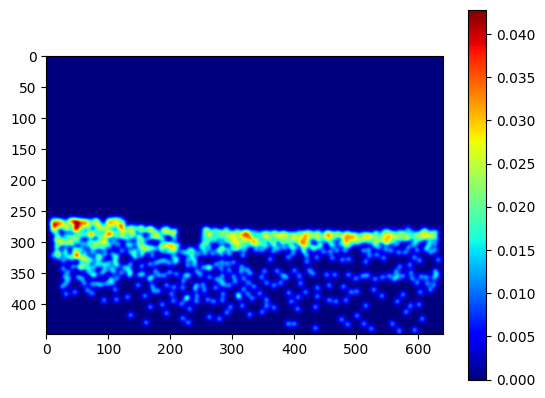

True count: 700
Density sum: 700.0


In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/crowd_data/UCF_CC_50/10.jpg")
points = sio.loadmat("/content/crowd_data/UCF_CC_50/10_ann.mat")["annPoints"]

density = generate_density_map(img.shape, points)

plt.imshow(density, cmap="jet")
plt.colorbar()
plt.show()

print("True count:", len(points))
print("Density sum:", density.sum())

In [ ]:
import numpy as np

def random_crop(img, density, size=256):
    h, w = img.shape[:2]

    x = np.random.randint(0, w-size)
    y = np.random.randint(0, h-size)

    return img[y:y+size, x:x+size], density[y:y+size, x:x+size]

In [ ]:
img_crop, den_crop = random_crop(img, density, 256)

print(img_crop.shape, den_crop.shape)


(256, 256, 3) (256, 256)


In [ ]:
import cv2

def downscale_density(d):
    d_small = cv2.resize(d, (d.shape[1]//8, d.shape[0]//8))
    return d_small * 64


In [ ]:
import torchvision.transforms as T

transform = T.ToTensor()

def prepare_sample(img_patch, den_patch):
    img_t = transform(img_patch)
    den_t = torch.tensor(den_patch).unsqueeze(0)
    return img_t, den_t

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

In [ ]:
class CrowdNet(nn.Module):
    def __init__(self):
        super().__init__()

        vgg = models.vgg16(weights="IMAGENET1K_V1")

        self.frontend = nn.Sequential(*list(vgg.features.children())[:23])

        self.backend = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=2, dilation=2),
            nn.ReLU(),
            nn.Conv2d(512, 256, 3, padding=2, dilation=2),
            nn.ReLU(),
            nn.Conv2d(256, 128, 3, padding=2, dilation=2),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, padding=2, dilation=2),
            nn.ReLU(),
        )

        self.output_layer = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        x = self.output_layer(x)
        return x


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CrowdNet().to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 80.6MB/s]


In [ ]:
model.eval()

img_t, den_t = prepare_sample(img_crop, downscale_density(den_crop))

with torch.no_grad():
    pred = model(img_t.unsqueeze(0).to(device))

print(pred.shape)

torch.Size([1, 1, 32, 32])


In [ ]:
import os
from torch.utils.data import Dataset

class CrowdDataset(Dataset):
    def __init__(self, root_dir, patch_size=256, patches_per_image=40):
        self.root_dir = root_dir
        self.patch_size = patch_size
        self.patches_per_image = patches_per_image

        # keep only image files
        self.img_files = [f for f in os.listdir(root_dir) if f.endswith(".jpg")]

    def __len__(self):
        return len(self.img_files) * self.patches_per_image

    def __getitem__(self, idx):
        file_idx = idx // self.patches_per_image
        img_name = self.img_files[file_idx]

        img_path = os.path.join(self.root_dir, img_name)
        ann_path = os.path.join(
            self.root_dir,
            img_name.replace(".jpg", "_ann.mat")
        )

        img = cv2.imread(img_path)
        mat = sio.loadmat(ann_path)
        points = mat["annPoints"]

        density = generate_density_map(img.shape, points)

        img_crop, den_crop = random_crop(img, density, self.patch_size)
        den_crop = downscale_density(den_crop)

        img_t, den_t = prepare_sample(img_crop, den_crop)

        return img_t, den_t


In [ ]:
dataset = CrowdDataset(
    root_dir="/content/crowd_data/UCF_CC_50",
    patch_size=256,
    patches_per_image=40
)

from torch.utils.data import DataLoader
loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2)


In [ ]:
epochs = 10

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for imgs, dens in loader:
        imgs = imgs.to(device)
        dens = dens.to(device)

        preds = model(imgs)
        loss = criterion(preds, dens)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    print(f"Epoch {epoch+1}/{epochs}  Loss: {avg_loss:.4f}")

Epoch 1/10  Loss: 0.0508
Epoch 2/10  Loss: 0.0347
Epoch 3/10  Loss: 0.0327
Epoch 4/10  Loss: 0.0236
Epoch 5/10  Loss: 0.0195
Epoch 6/10  Loss: 0.0170
Epoch 7/10  Loss: 0.0126
Epoch 8/10  Loss: 0.0115
Epoch 9/10  Loss: 0.0105
Epoch 10/10  Loss: 0.0084


In [ ]:
def predict_count_full_image(img_path, mat_path):
    model.eval()

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    # resize to multiple of 8
    h8 = h - h % 8
    w8 = w - w % 8
    img = cv2.resize(img, (w8, h8))

    img_t = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_t)

    pred_count = pred.sum().item()

    # true count
    mat = sio.loadmat(mat_path)
    true_count = len(mat["annPoints"])

    return pred_count, true_count, pred.squeeze().cpu().numpy()


In [ ]:
img_path = "/content/crowd_data/UCF_CC_50/1.jpg"
mat_path = "/content/crowd_data/UCF_CC_50/1_ann.mat"

pred_c, true_c, pred_map = predict_count_full_image(img_path, mat_path)

print("True count:", true_c)
print("Predicted:", round(pred_c))

True count: 4633
Predicted: 4405


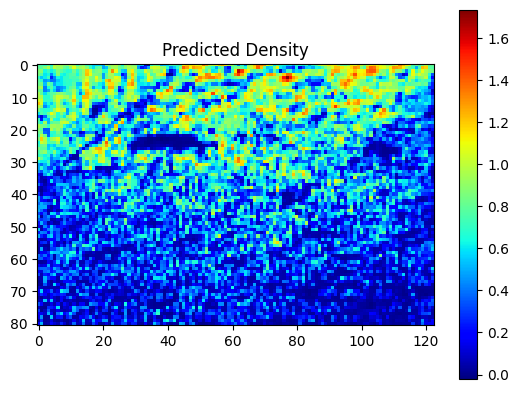

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(pred_map, cmap="jet")
plt.title("Predicted Density")
plt.colorbar()
plt.show()


In [ ]:
import numpy as np

def evaluate_dataset(root):
    errors = []
    sq_errors = []

    files = [f for f in os.listdir(root) if f.endswith(".jpg")]

    for name in files:
        img_path = os.path.join(root, name)
        mat_path = os.path.join(root, name.replace(".jpg","_ann.mat"))

        pred, true, _ = predict_count_full_image(img_path, mat_path)

        err = abs(pred - true)
        errors.append(err)
        sq_errors.append(err**2)

        print(name, "True:", true, "Pred:", round(pred))

    mae = np.mean(errors)
    rmse = np.sqrt(np.mean(sq_errors))

    print("\nMAE:", mae)
    print("RMSE:", rmse)

In [ ]:
evaluate_dataset("/content/crowd_data/UCF_CC_50")

15.jpg True: 1543 Pred: 1573
49.jpg True: 588 Pred: 612
5.jpg True: 469 Pred: 403
41.jpg True: 1284 Pred: 1284
10.jpg True: 700 Pred: 657
14.jpg True: 2961 Pred: 2902
23.jpg True: 679 Pred: 705
43.jpg True: 947 Pred: 815
6.jpg True: 2550 Pred: 2581
26.jpg True: 2391 Pred: 2095
33.jpg True: 311 Pred: 291
31.jpg True: 1998 Pred: 1753
35.jpg True: 1050 Pred: 1008
12.jpg True: 581 Pred: 570
38.jpg True: 440 Pred: 384
17.jpg True: 362 Pred: 380
28.jpg True: 1739 Pred: 1480
1.jpg True: 4633 Pred: 4405
32.jpg True: 562 Pred: 560
9.jpg True: 3406 Pred: 3372
39.jpg True: 164 Pred: 210
47.jpg True: 1961 Pred: 1834
37.jpg True: 917 Pred: 1049
48.jpg True: 2372 Pred: 2313
45.jpg True: 1451 Pred: 1287
7.jpg True: 648 Pred: 609
4.jpg True: 96 Pred: 94
19.jpg True: 754 Pred: 741
30.jpg True: 248 Pred: 262
21.jpg True: 376 Pred: 381
2.jpg True: 1940 Pred: 1640
27.jpg True: 1858 Pred: 1809
50.jpg True: 440 Pred: 398
18.jpg True: 682 Pred: 693
3.jpg True: 2364 Pred: 2101
34.jpg True: 1115 Pred: 1047
11.

In [ ]:
torch.save(model.state_dict(), "crowd_density_cc50_v1.pth")


In [ ]:
from google.colab import files

files.download('crowd_density_cc50_v1.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.load_state_dict(torch.load("crowd_density_cc50_v1.pth"))
model.eval()

CrowdNet(
  (frontend): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilat

In [ ]:
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np

def show_prediction_with_density(img_path):

    # ---------- Load image ----------
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]
    h8 = h - h % 8
    w8 = w - w % 8
    img_resized = cv2.resize(img_rgb, (w8, h8))

    # ---------- True count ----------
    mat = sio.loadmat(img_path.replace(".jpg", "_ann.mat"))
    points = mat["annPoints"]
    true_count = len(points)

    # ---------- Ground truth density ----------
    gt_density = generate_density_map(img_resized.shape, points)

    # ---------- Model prediction ----------
    img_t = transform(img_resized).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_map = model(img_t).squeeze().cpu().numpy()

    pred_count = pred_map.sum()

    # ---------- Upscale predicted density for display ----------
    pred_map_up = cv2.resize(
        pred_map,
        (img_resized.shape[1], img_resized.shape[0])
    )

    # ---------- Plot ----------
    plt.figure(figsize=(16,5))

    # Image
    plt.subplot(1,3,1)
    plt.imshow(img_resized)
    plt.title(f"Image\nTrue: {true_count} | Pred: {int(pred_count)}")
    plt.axis("off")

    # Ground truth density
    plt.subplot(1,3,2)
    plt.imshow(gt_density, cmap="jet")
    plt.title("Ground Truth Density")
    plt.axis("off")

    # Predicted density
    plt.subplot(1,3,3)
    plt.imshow(pred_map_up, cmap="jet")
    plt.title("Predicted Density")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("True Count:", true_count)
    print("Predicted Count:", int(pred_count))


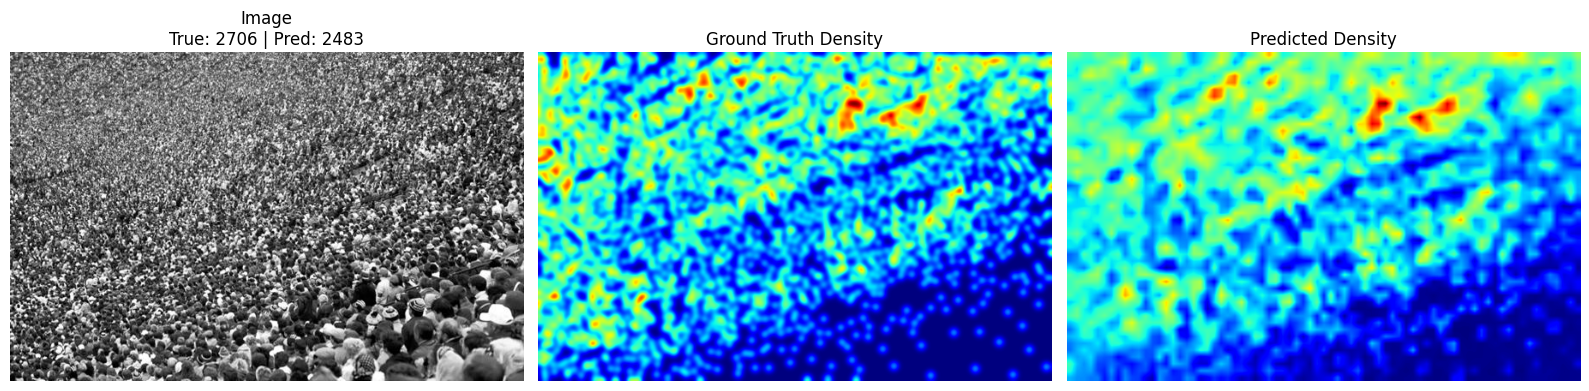

True Count: 2706
Predicted Count: 2483


In [ ]:
show_prediction_with_density(
    "/content/crowd_data/UCF_CC_50/20.jpg"
)